# Sinusoidal Injection & Recovery Test

Inject a known CW sinusoid $A\cos(2\pi f_{\rm sig} t + \phi)$ into the raw strain,
run the full preprocessing pipeline, and verify recovery in baseband.

After heterodyning by $e^{-2\pi i f_h t}$ and decimation, the sinusoid appears at
baseband frequency $\Delta f = f_{\rm sig} - f_h$ with amplitude $A/2$.

**Subtraction method**: run the pipeline with and without injection, then
analyze the difference to isolate the pipeline's response to the pure sinusoid.

In [11]:
import readligo
from readligo import process_band
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [12]:
dirname = "/Users/saifa/Library/CloudStorage/OneDrive-weizmann.ac.il/O3a_marvin/"
hdf5_files = list(Path(dirname).glob("*.hdf5"))
hdf5_files_sorted = sorted(
    hdf5_files,
    key=lambda p: int(p.stem.split('-')[-2])
)

filename = hdf5_files_sorted[0].name
strain, time, channel_dict = readligo.loaddata(dirname + filename)
_, gpsStart, ts, *_ = readligo.read_hdf5(dirname + filename)
fs = 4096
print(f"File: {filename}")
print(f"GPS start: {gpsStart}")
print(f"Strain shape: {strain.shape}")

File: H-H1_GWOSC_O3a_4KHZ_R1-1238163456-4096.hdf5
GPS start: 1238163456.0
Strain shape: (16777216,)


## Injection parameters

In [13]:
# Band and injection frequency
f_band = (100, 101)
f_h = (f_band[0] + f_band[1]) / 2   # 100.5 Hz
f_sig = 100.3                         # injection frequency
delta_f = f_sig - f_h                 # -0.2 Hz in baseband
phi = 0                       # injection phase

# First run pipeline without injection to measure narrowband noise level
gps_0, cleaned_0, mask_0, fs_new = process_band(
    strain, channel_dict, gpsStart, f_band
)
nb_noise_rms = np.std(cleaned_0[mask_0])

# Amplitude: 5x narrowband noise RMS (SNR ~5 per sample)
A_inj = 5 * nb_noise_rms * 2  # factor 2: baseband amplitude is A/2

print(f"f_sig             = {f_sig} Hz")
print(f"delta_f           = {delta_f} Hz (baseband)")
print(f"phi               = {phi:.4f} rad ({np.degrees(phi):.1f} deg)")
print(f"nb_noise_rms      = {nb_noise_rms:.2e}")
print(f"A_inj             = {A_inj:.2e}")
print(f"A_inj / 2         = {A_inj/2:.2e} (expected baseband amplitude)")
print(f"SNR per sample    = {(A_inj/2) / nb_noise_rms:.1f}")

f_sig             = 100.3 Hz
delta_f           = -0.20000000000000284 Hz (baseband)
phi               = 0.0000 rad (0.0 deg)
nb_noise_rms      = 4.04e-24
A_inj             = 4.04e-23
A_inj / 2         = 2.02e-23 (expected baseband amplitude)
SNR per sample    = 5.0


In [14]:
# Create injected strain
t_raw = np.arange(len(strain)) / fs
injection_raw = A_inj * np.cos(2 * np.pi * f_sig * t_raw + phi)
strain_injected = strain + injection_raw

## Run pipeline: with and without injection

In [15]:
# cleaned_0, mask_0 already computed in the parameters cell
gps_1, cleaned_1, mask_1, fs_new = process_band(
    strain_injected, channel_dict, gpsStart, f_band
)

# Compare masks
mask_diff = mask_0 != mask_1
n_diff = np.sum(mask_diff)
if n_diff == 0:
    print("Masks identical -- CW not flagged by transient cleaning.")
else:
    print(f"Masks differ at {n_diff} samples.")
    diff_idx = np.where(mask_diff)[0]
    print(f"  First differing indices: {diff_idx[:10]}")
    print(f"  mask_0 (no inj):  {mask_0[diff_idx[:10]]}")
    print(f"  mask_1 (with inj): {mask_1[diff_idx[:10]]}")
    lost = np.sum(mask_0 & ~mask_1)
    gained = np.sum(~mask_0 & mask_1)
    print(f"  Good→Bad (lost): {lost},  Bad→Good (gained): {gained}")

# Use intersection of good samples for fair comparison
good = mask_0 & mask_1
residual = cleaned_1 - cleaned_0
residual_good = residual[good]
t_ds = np.arange(len(residual)) / fs_new
t_good = t_ds[good]

print(f"\nTotal samples: {len(residual)}")
print(f"Good in both masks: {np.sum(good)}")
print(f"Injection / noise ratio: {(A_inj/2) / np.std(cleaned_0[good]):.1f}")

Masks identical -- CW not flagged by transient cleaning.

Total samples: 4096
Good in both masks: 1408
Injection / noise ratio: 5.0


## FFT recovery

In [16]:
# --- Step 1: Frequency estimation via zero-padded FFT ---
N = len(residual)
pad_factor = 16
N_pad = N * pad_factor
freqs_pad = np.fft.fftfreq(N_pad, d=1.0 / fs_new)
spectrum_pad = np.fft.fft(residual, n=N_pad) / N
power_pad = np.abs(spectrum_pad) ** 2
peak_idx = np.argmax(power_pad)
f_recovered = freqs_pad[peak_idx]

# --- Step 2: Amplitude & phase via DTFT on good samples only ---
# Evaluating at f_recovered using only good samples avoids the
# window-convolution bias that zero-filling introduces.
basis = np.exp(-2j * np.pi * f_recovered * t_good)
N_good = np.sum(good)
h_fft = np.dot(residual_good, basis) / N_good

A_baseband_fft = np.abs(h_fft)
phi_fft = np.angle(h_fft)

print(f"=== FFT Recovery (corrected) ===")
print(f"{'':30s} {'Injected':>12s} {'Recovered':>12s} {'Error':>12s}")
print(f"{'Baseband freq (Hz)':30s} {delta_f:12.4f} {f_recovered:12.4f} {f_recovered - delta_f:12.6f}")
print(f"{'Baseband amplitude':30s} {A_inj/2:12.2e} {A_baseband_fft:12.2e} {A_baseband_fft/(A_inj/2):12.4f} (ratio)")
print(f"{'Phase (rad)':30s} {phi:12.4f} {phi_fft:12.4f} {phi_fft - phi:12.4f}")

=== FFT Recovery (corrected) ===
                                   Injected    Recovered        Error
Baseband freq (Hz)                  -0.2000      -0.2000     0.000003
Baseband amplitude                 2.02e-23     2.02e-23       1.0014 (ratio)
Phase (rad)                          0.0000      -0.0649      -0.0649


## Matched-filter recovery

In [17]:
# Project residual onto template at known frequency (good samples only)
template = np.exp(2j * np.pi * delta_f * t_good)
h_hat = np.dot(residual_good, template.conj()) / np.dot(template, template.conj())

A_mf = np.abs(h_hat) * 2      # factor 2: baseband amplitude is A/2
phi_mf = np.angle(h_hat)

# SNR
noise_rms = np.std(cleaned_0[good])
snr_per_sample = (A_inj / 2) / noise_rms
snr_cumulative = snr_per_sample * np.sqrt(np.sum(good))

print(f"=== Matched-Filter Recovery ===")
print(f"{'':30s} {'Injected':>12s} {'Recovered':>12s} {'Error':>12s}")
print(f"{'Amplitude':30s} {A_inj:12.2e} {A_mf:12.2e} {A_mf/A_inj:12.4f} (ratio)")
print(f"{'Phase (rad)':30s} {phi:12.4f} {phi_mf:12.4f} {phi_mf - phi:12.4f}")
print(f"")
print(f"Baseband noise RMS:   {noise_rms:.2e}")
print(f"SNR per sample:       {snr_per_sample:.2f}")
print(f"Cumulative SNR:       {snr_cumulative:.1f}")

=== Matched-Filter Recovery ===
                                   Injected    Recovered        Error
Amplitude                          4.04e-23     4.04e-23       1.0014 (ratio)
Phase (rad)                          0.0000      -0.0000      -0.0000

Baseband noise RMS:   4.04e-24
SNR per sample:       5.00
Cumulative SNR:       187.6


## Diagnostic plots

NameError: name 'freqs' is not defined

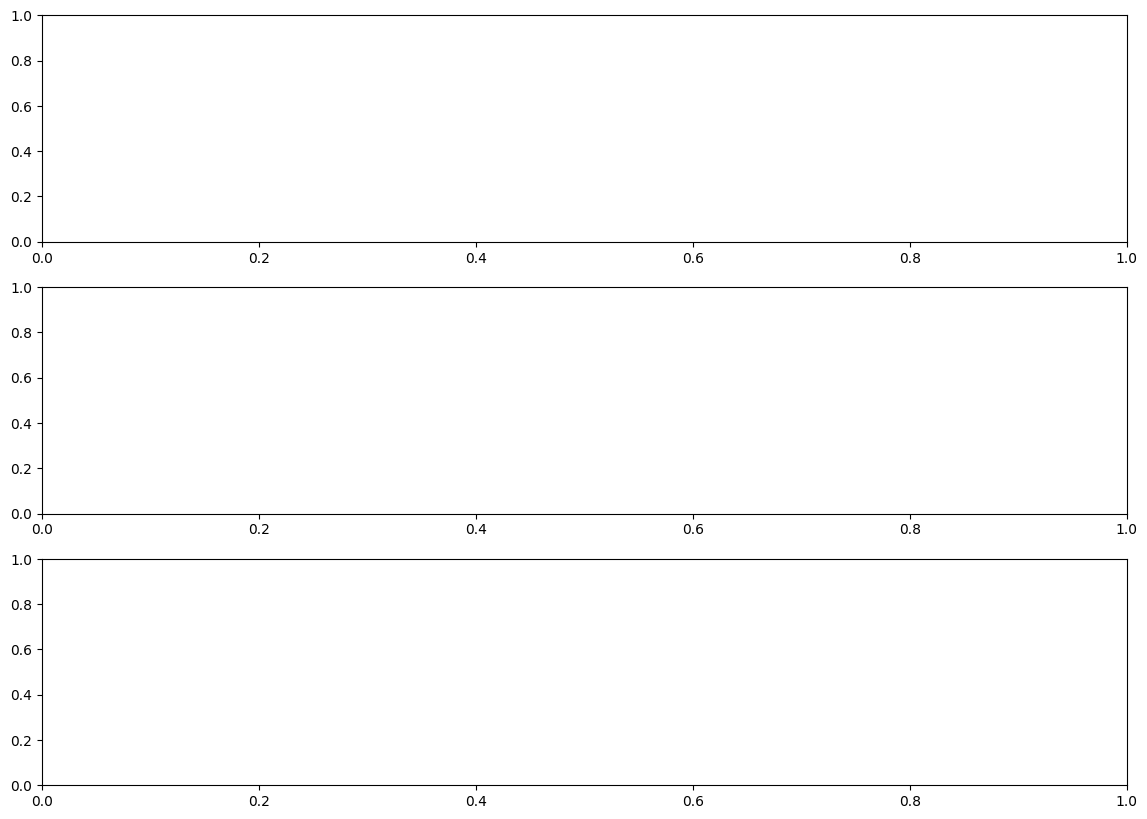

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Baseband power spectrum
freqs_shifted = np.fft.fftshift(freqs)
power_shifted = np.fft.fftshift(power)
# Noise-only spectrum for comparison
spec_noise = np.fft.fft(cleaned_0) / N
power_noise = np.fft.fftshift(np.abs(spec_noise) ** 2)

axes[0].semilogy(freqs_shifted, power_noise, color="gray", alpha=0.5, lw=0.5, label="noise only")
axes[0].semilogy(freqs_shifted, power_shifted, color="steelblue", lw=0.5, label="with injection")
axes[0].axvline(delta_f, color="red", ls="--", lw=1, label=f"injected: {delta_f} Hz")
axes[0].set_xlabel("Baseband frequency (Hz)")
axes[0].set_ylabel("Power")
axes[0].set_title("Baseband power spectrum (residual)")
axes[0].legend()
axes[0].set_xlim(-0.5, 0.5)

# Panel 2: Time-domain residual amplitude
axes[1].plot(t_ds, np.abs(residual), lw=0.5, color="steelblue")
axes[1].axhline(A_inj / 2, color="red", ls="--", lw=1, label=f"expected |A/2| = {A_inj/2:.2e}")
# Shade masked regions
bad_regions = np.where(~good)[0]
if len(bad_regions) > 0:
    for start_idx in np.split(bad_regions, np.where(np.diff(bad_regions) > 1)[0] + 1):
        axes[1].axvspan(t_ds[start_idx[0]], t_ds[start_idx[-1]], color="red", alpha=0.1)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("|residual|")
axes[1].set_title("Time-domain residual (red shading = masked)")
axes[1].legend()

# Panel 3: Chunked amplitude ratio
chunk_size = 64
good_idx = np.where(good)[0]
n_chunks = len(good_idx) // chunk_size
chunk_amps = []
chunk_times = []
for c in range(n_chunks):
    idx = good_idx[c * chunk_size : (c + 1) * chunk_size]
    t_chunk = t_ds[idx]
    template_chunk = np.exp(2j * np.pi * delta_f * t_chunk)
    h_chunk = np.dot(residual[idx], template_chunk.conj()) / np.dot(template_chunk, template_chunk.conj())
    chunk_amps.append(np.abs(h_chunk) / (A_inj / 2))
    chunk_times.append(np.mean(t_chunk))

axes[2].plot(chunk_times, chunk_amps, "o-", ms=3, lw=0.8, color="steelblue")
axes[2].axhline(1.0, color="red", ls="--", lw=1, label="ideal = 1.0")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude ratio")
axes[2].set_title("Recovered / expected amplitude per 64-sample chunk")
axes[2].legend()

plt.tight_layout()
plt.show()

## Multi-frequency verification

Inject at several frequencies across the band and check that:
1. Matched-filter amplitude and phase are consistent across frequencies
2. FFT phase offset varies linearly with $\Delta f$ (consistent with a constant group delay from zero-filling)

In [ ]:
# Inject at multiple frequencies, recover with both FFT and matched filter
test_freqs = [100.1, 100.2, 100.3, 100.4, 100.45]
results = []

for f_test in test_freqs:
    df_test = f_test - f_h
    inj_test = A_inj * np.cos(2 * np.pi * f_test * t_raw + phi)
    strain_test = strain + inj_test

    _, cleaned_test, mask_test, _ = process_band(
        strain_test, channel_dict, gpsStart, f_band
    )

    good_test = mask_0 & mask_test
    res_test = cleaned_test - cleaned_0
    res_good = res_test[good_test]
    t_good_test = t_ds[good_test]

    # FFT recovery
    spec_test = np.fft.fft(res_test) / N
    power_test = np.abs(spec_test) ** 2
    peak_i = np.argmax(power_test)
    duty_test = np.sum(good_test) / N
    A_fft_test = np.abs(spec_test[peak_i]) / duty_test
    phi_fft_test = np.angle(spec_test[peak_i])

    # Matched-filter recovery
    tmpl = np.exp(2j * np.pi * df_test * t_good_test)
    h = np.dot(res_good, tmpl.conj()) / np.dot(tmpl, tmpl.conj())
    A_mf_test = np.abs(h) * 2
    phi_mf_test = np.angle(h)

    results.append({
        "f_sig": f_test,
        "delta_f": df_test,
        "A_mf_ratio": A_mf_test / A_inj,
        "phi_mf_err": phi_mf_test - phi,
        "A_fft_ratio": A_fft_test / (A_inj / 2),
        "phi_fft_err": phi_fft_test - phi,
    })

# Print results table
print(f"{'f_sig':>7s} {'delta_f':>8s} | {'MF A ratio':>10s} {'MF phi err':>10s} | {'FFT A ratio':>11s} {'FFT phi err':>11s}")
print("-" * 72)
for r in results:
    print(f"{r['f_sig']:7.2f} {r['delta_f']:8.3f} | "
          f"{r['A_mf_ratio']:10.4f} {r['phi_mf_err']:10.4f} | "
          f"{r['A_fft_ratio']:11.4f} {r['phi_fft_err']:11.4f}")

# Check if FFT phase error is linear in delta_f (=> constant group delay)
delta_fs = np.array([r["delta_f"] for r in results])
phi_fft_errs = np.array([r["phi_fft_err"] for r in results])
# Linear fit: phi_err = 2*pi*delta_f*tau + offset
coeffs = np.polyfit(delta_fs, phi_fft_errs, 1)
tau_eff = coeffs[0] / (2 * np.pi)
print(f"\nFFT phase error linear fit: slope = {coeffs[0]:.4f} rad/Hz, "
      f"intercept = {coeffs[1]:.4f} rad")
print(f"Effective delay (slope / 2pi): tau = {tau_eff:.3f} s")
print(f"Residual from linear fit (RMS): {np.sqrt(np.mean((phi_fft_errs - np.polyval(coeffs, delta_fs))**2)):.4f} rad")

In [ ]:
# Band and injection frequency
f_band = (100, 101)
f_h = (f_band[0] + f_band[1]) / 2   # 100.5 Hz
f_sig = 100.3                        # injection frequency
delta_f = f_sig - f_h                 # -0.2 Hz in baseband
phi = np.pi / 3                       # injection phase
fs = 4096

# First run pipeline without injection to measure narrowband noise level
gps_0, cleaned_0, mask_0, fs_new = process_band(
    strain, channel_dict, gpsStart, f_band
)
nb_noise_rms = np.std(cleaned_0[mask_0])

# Amplitude: 5x narrowband noise RMS (SNR ~5 per sample)
A_inj = 5 * nb_noise_rms * 2  # factor 2: baseband amplitude is A/2

print(f"f_sig             = {f_sig} Hz")
print(f"delta_f           = {delta_f} Hz (baseband)")
print(f"phi               = {phi:.4f} rad ({np.degrees(phi):.1f} deg)")
print(f"nb_noise_rms      = {nb_noise_rms:.2e}")
print(f"A_inj             = {A_inj:.2e}")
print(f"A_inj / 2         = {A_inj/2:.2e} (expected baseband amplitude)")
print(f"SNR per sample    = {(A_inj/2) / nb_noise_rms:.1f}")

In [ ]:
# Create injected strain
t_raw = np.arange(len(strain)) / fs
injection_raw = A_inj * np.exp(1j * (2 * np.pi * f_sig * t_raw + phi))

In [ ]:
# 2. Take the FFT
fft_signal = np.fft.fft(injection_raw)
# 3. Find the index of the maximum MAGNITUDE
peak_idx = np.argmax(np.abs(fft_signal))
# 4. Extract the complex value at that index
peak_complex_value = fft_signal[peak_idx]
# 5. Measure phase and amplitude
measured_phi = np.angle(peak_complex_value)
measured_amp = np.abs(peak_complex_value) / len(t_raw) # Normalize by N
print(f"Measured Phase: {measured_phi}")
print(f"Measured Amp: {measured_amp}")

In [ ]:
# 1. EMPIRICAL: What the FFT actually added
# We subtract the injected phase from the measured phase.
# (We wrap it in np.angle(np.exp(1j * ...)) just in case it wraps past pi or -pi)
theta_leak_empirical = np.angle(np.exp(1j * (measured_phi - phi)))

# 2. THEORETICAL: The exact math of the frequency mismatch
N = len(t_raw)
T = N / fs
dt = 1.0 / fs

# Find the exact frequency of the FFT bin
freqs = np.fft.fftfreq(N, d=dt)
f_k = freqs[peak_idx]

# Calculate the mismatch (delta)
delta = f_sig - f_k

# The exact mathematical formula for the phase drift of a discrete geometric series:
# theta_leak = pi * delta * (T - dt)
theta_leak_theoretical = np.pi * delta * (T - dt)

print(f"Injected phi:           {phi}")
print(f"Measured phi:           {measured_phi}")
print(f"------------------------------------------------")
print(f"Empirical theta_leak:   {theta_leak_empirical}")
print(f"Theoretical theta_leak: {theta_leak_theoretical}")

In [9]:
import numpy as np
from injection_recovery_script import InjectionRecovery

inj_rec = InjectionRecovery(
    fs=4096,
    f_band=(100, 101),
    f_sig=100.3,
    amplitude=1e-2,
    sky_pos=(0.3, 0.2),
    gps_start=1238163456.0,
    duration=128,
    detector_name="H1",
)

results = inj_rec.recovered_scores(200)

Running simulations:   0%|          | 0/200 [00:00<?, ?it/s]

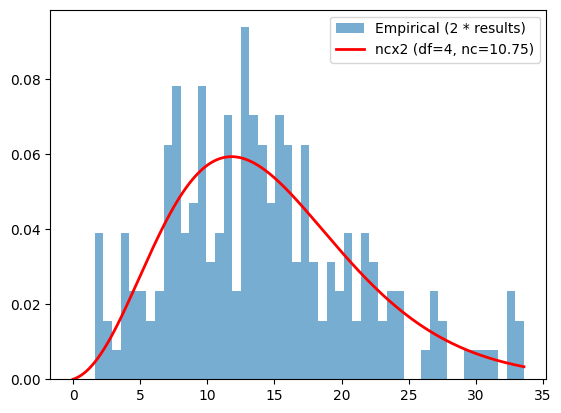

In [10]:
from scipy.stats import ncx2


plt.hist(2 * results, bins=50, density=True, alpha=0.6, label='Empirical (2 * results)')

df = 4
nc = 2 * inj_rec.optimal_snr_sq

# 3. Plot the theoretical PDF
x = np.linspace(0, max(2 * results), 500)
pdf = ncx2.pdf(x, df, nc)
plt.plot(x, pdf, 'r-', lw=2, label=f'ncx2 (df={df}, nc={nc:.2f})')

plt.legend()
plt.show()